In [ ]:
import numpy as np
np.set_printoptions(suppress=True)

# Task 1 — Tensor Manipulations (NumPy)


In [ ]:
a = np.array([[1, 2, 3],                    # define a 2x3 matrix (dtype float32 for NN-friendly math)
              [4, 5, 6]], dtype=np.float32)     # rows are [1,2,3] and [4,5,6]
b = np.ones((2, 3), dtype=np.float32) * 10      # 2x3 matrix full of 10s, matches shape of 'a'
print("a:\n", a)                                # inspect 'a' to verify shape and values
print("b:\n", b)                                # inspect 'b' to verify shape and values

a:
 [[1. 2. 3.]
 [4. 5. 6.]]
b:
 [[10. 10. 10.]
 [10. 10. 10.]]


In [ ]:
c_add = a + b                             # element-wise addition since shapes align (2x3)
print("a + b:\n", c_add)                        # result: each entry is a_ij + b_ij

a + b:
 [[11. 12. 13.]
 [14. 15. 16.]]


In [ ]:
c_add = a + b                             # element-wise addition since shapes align (2x3)
print("a + b:\n", c_add)                        # result: each entry is a_ij + b_ij

a + b:
 [[11. 12. 13.]
 [14. 15. 16.]]


In [ ]:
c_mul = a * b                             # element-wise multiplication (Hadamard product)
print("a * b:\n", c_mul)                        # each entry is a_ij * b_ij

a * b:
 [[10. 20. 30.]
 [40. 50. 60.]]


In [ ]:
r = np.reshape(a, (3, 2))                # reshape without changing data: (2,3) -> (3,2)
# r = a.reshape(3, 2)                               # equivalent method call on the array
print("reshape (3,2):\n", r)                     # confirm new shape and layout

reshape (3,2):
 [[1. 2.]
 [3. 4.]
 [5. 6.]]


In [ ]:
print("first row:", a[0])                 # index row 0 -> [1,2,3]
print("second column:", a[:, 1])              # slice all rows, column index 1 -> [2,5]
print("submatrix:\n", a[0:2, 1:3])           # rows [0..1], cols [1..2] -> [[2,3],[5,6]]

first row: [1. 2. 3.]
second column: [2. 5.]
submatrix:
 [[2. 3.]
 [5. 6.]]


In [ ]:
# concatenate vs stack: concatenate joins along an existing axis; stack creates a new axis
cat_cols = np.concatenate([a, b], axis=1)      # concat columns -> shapes must match except axis=1 (now (2,6))
cat_rows = np.concatenate([a, b], axis=0)      # concat rows    -> result is (4,3)
stack0  = np.stack([a, b], axis=0)             # stack on new axis 0 -> shape (2,2,3)
stack2  = np.stack([a, b], axis=2)             # stack on new axis 2 -> shape (2,3,2)
print("concat cols:\n", cat_cols)             # visualize concatenated columns
print("concat rows:\n", cat_rows)             # visualize concatenated rows
print("stack axis=0 shape:", stack0.shape)     # check shape to understand added axis
print("stack axis=2 shape:", stack2.shape)     # check shape to understand added axis

concat cols:
 [[ 1.  2.  3. 10. 10. 10.]
 [ 4.  5.  6. 10. 10. 10.]]
concat rows:
 [[ 1.  2.  3.]
 [ 4.  5.  6.]
 [10. 10. 10.]
 [10. 10. 10.]]
stack axis=0 shape: (2, 2, 3)
stack axis=2 shape: (2, 3, 2)


In [ ]:
x = np.arange(12).reshape(3, 4)                 # numbers 0..11 reshaped into 3x4 grid
left, right = np.split(x, 2, axis=1)            # split columns into 2 equal parts -> (3,2) and (3,2)
top, middle_bottom = np.split(x, [1], axis=0)   # split rows at index 1 -> (1,4) and (2,4)
print("left:\n", left)                          # left half of columns
print("right:\n", right)                        # right half of columns

left:
 [[0 1]
 [4 5]
 [8 9]]
right:
 [[ 2  3]
 [ 6  7]
 [10 11]]


In [ ]:
print("sum:", a.sum())                      # reduce over all elements -> scalar
print("mean (axis=0):", a.mean(axis=0))        # column-wise mean -> shape (3,)
print("max:", a.max())                         # global maximum value
print("transpose a^T:\n", a.T)                # swap axes: (2,3) -> (3,2)
w = np.arange(6, dtype=np.float32).reshape(3, 2)  # make a 3x2 matrix for matmul
print("matrix multiply (2x3) @ (3x2):\n", a @ w) # matrix product -> result (2,2)
print("elementwise relu:", np.maximum(a, 0))   # ReLU nonlinearity: negative -> 0, positive -> itself

sum: 21.0
mean (axis=0): [2.5 3.5 4.5]
max: 6.0
transpose a^T:
 [[1. 4.]
 [2. 5.]
 [3. 6.]]
matrix multiply (2x3) @ (3x2):
 [[16. 22.]
 [34. 49.]]
elementwise relu: [[1. 2. 3.]
 [4. 5. 6.]]


# Task 2 — Neural Network Foundations (Keras)
##Setup

In [9]:
import tensorflow as tf                 # deep learning backend
from tensorflow import keras              # Keras high-level API
from tensorflow.keras import layers       # common layers: Dense, Dropout, etc.
tf.random.set_seed(42)                    # reproducibility for weights/init

In [10]:
# 2-layer MLP mapping 20-D inputs -> 3 classes
model = keras.Sequential([
    layers.Input(shape=(20,)),           # placeholder for feature vector length 20
    layers.Dense(16, activation="relu"), # hidden layer with ReLU nonlinearity
    layers.Dense(3, activation="softmax")# 3-way classification -> probabilities sum to 1
])

In [11]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),      # adaptive optimizer with lr=0.001
    loss="sparse_categorical_crossentropy",     # integer labels (0..2) -> sparse variant
    metrics=["accuracy"]                         # track accuracy during training/eval
)

In [12]:
model.summary()                         # print param counts and layer shapes


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387 (1.51 KB)

 Trainable params: 387 (1.51 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
import numpy as np                        # create synthetic data to sanity-check pipeline
X = np.random.randn(256, 20).astype("float32")  # 256 samples, each 20-D features
y = np.random.randint(0, 3, size=(256,))        # random integer class labels in [0,3)
history = model.fit(                            # quick overfit/shape sanity-check
    X, y,
    epochs=3,                                   # few epochs just to see training loop
    batch_size=32,                              # typical small batch
    validation_split=0.2                        # hold out 20% for validation
)

Epoch 1/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.2803 - loss: 1.4434 - val_accuracy: 0.4808 - val_loss: 1.1409
Epoch 2/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2911 - loss: 1.4044 - val_accuracy: 0.4808 - val_loss: 1.1359
Epoch 3/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2958 - loss: 1.3755 - val_accuracy: 0.4808 - val_loss: 1.1319


# Task 3 Classification MNIST and IMDB Kears

## A MNIST setup

In [14]:
import tensorflow as tf                 # TensorFlow/Keras
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt            # plot training curves
tf.random.set_seed(42)                     # reproducible splits/initialization

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data() # 28x28 images
x_train = (x_train.astype("float32") / 255.0).reshape(-1, 784)  # scale to [0,1] then flatten -> (N,784)
x_test  = (x_test.astype("float32")  / 255.0).reshape(-1, 784)  # same preprocessing for test set
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape) # sanity-check shapes/labels

In [ ]:
mnist_model = keras.Sequential([
    layers.Input(shape=(784,)),               # flattened 28x28 image
    layers.Dense(128, activation="relu"),     # hidden layer for representation
    layers.Dropout(0.2),                      # regularize to reduce overfitting
    layers.Dense(10, activation="softmax")    # 10 classes (digits 0..9)
])

In [ ]:
mnist_model.compile(
    optimizer="adam",                         # Adam works well out of the box
    loss="sparse_categorical_crossentropy",   # integer digit labels
    metrics=["accuracy"]                      # track accuracy
)

In [ ]:
history_mnist = mnist_model.fit(
    x_train, y_train,
    epochs=5,                                 # quick training for demo
    batch_size=128,                           # larger batch speeds up on GPU/TPU
    validation_split=0.1,                     # 10% of train data for validation
    verbose=1                                 # show progress
)

In [ ]:
test_loss, test_acc = mnist_model.evaluate(x_test, y_test, verbose=0)  # final test metrics
print(f"MNIST — test loss: {test_loss:.4f} | test acc: {test_acc:.4f}")                # report metrics

# Plot loss over epochs to diagnose under/overfitting
plt.figure()
plt.plot(history_mnist.history["loss"], label="train loss")      # training loss curve
plt.plot(history_mnist.history["val_loss"], label="val loss")    # validation loss curve
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("MNIST Loss")
plt.show()

# Plot accuracy to see learning progress
plt.figure()
plt.plot(history_mnist.history["accuracy"], label="train acc")        # training accuracy
plt.plot(history_mnist.history["val_accuracy"], label="val acc")      # validation accuracy
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.title("MNIST Accuracy")
plt.show()

# B IMDb

In [1]:
from tensorflow.keras.preprocessing.sequence import pad_sequences  # sequence padding util
from tensorflow import keras
num_words = 10_000                      # limit vocabulary to most frequent 10k words
maxlen = 200                            # fixed-length sequences for batching
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=num_words)  # load tokenized reviews
X_train = pad_sequences(X_train, maxlen=maxlen, truncating="post", padding="post")  # pad/cut to maxlen
X_test  = pad_sequences(X_test,  maxlen=maxlen, truncating="post", padding="post")  # same for test
print(X_train.shape, X_test.shape)      # both -> (25000, 200)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(25000, 200) (25000, 200)


In [16]:
imdb_model = keras.Sequential([
    keras.layers.Embedding(input_dim=num_words, output_dim=64),  # word embeddings
    keras.layers.GlobalAveragePooling1D(),                                            # average embeddings across tokens
    keras.layers.Dense(64, activation="relu"),                                        # hidden layer
    keras.layers.Dropout(0.2),                                                        # regularization
    keras.layers.Dense(1, activation="sigmoid")                                       # binary sentiment -> probability
])

In [15]:
imdb_model.compile(
    optimizer="adam",                    # default Adam
    loss="binary_crossentropy",          # binary labels (0/1)
    metrics=["accuracy"]                 # accuracy for readability
)

In [4]:
history_imdb = imdb_model.fit(
    X_train, y_train,
    epochs=6,                           # a few epochs for demo
    batch_size=512,                     # bigger batch for speed on accelerators
    validation_split=0.2,               # hold-out validation
    verbose=1                           # progress bar
)

Epoch 1/6
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.5704 - loss: 0.6880 - val_accuracy: 0.7066 - val_loss: 0.6484
Epoch 2/6
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.7292 - loss: 0.6218 - val_accuracy: 0.7806 - val_loss: 0.5210
Epoch 3/6
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7992 - loss: 0.4867 - val_accuracy: 0.8272 - val_loss: 0.4216
Epoch 4/6
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.8483 - loss: 0.3816 - val_accuracy: 0.8468 - val_loss: 0.3646
Epoch 5/6
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.8732 - loss: 0.3220 - val_accuracy: 0.8566 - val_loss: 0.3416
Epoch 6/6
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.8867 - loss: 0.2909 - val_accuracy: 0.8396 - val_loss: 0.3578


IMDb — test loss: 0.3815 | test acc: 0.8223


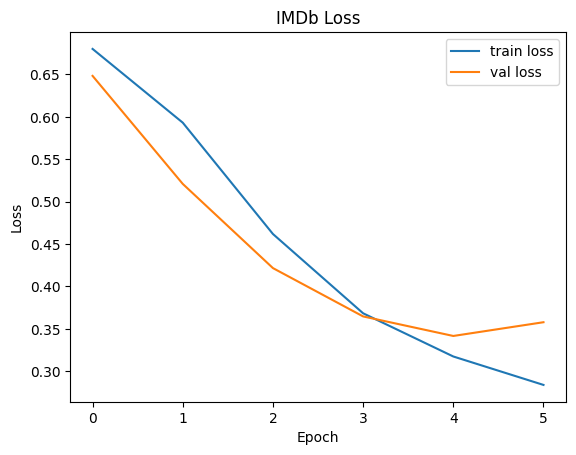

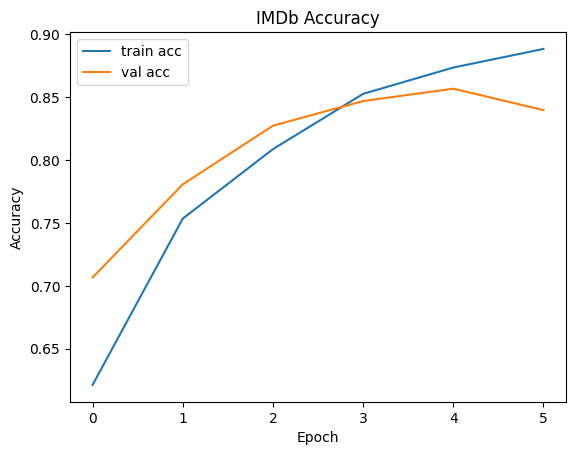

In [8]:
loss, acc = imdb_model.evaluate(X_test, y_test, verbose=0) # test set metrics
print(f"IMDb — test loss: {loss:.4f} | test acc: {acc:.4f}")

# Plot loss curves to inspect bias/variance
import matplotlib.pyplot as plt
plt.figure()
plt.plot(history_imdb.history["loss"], label="train loss")
plt.plot(history_imdb.history["val_loss"], label="val loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("IMDb Loss")
plt.show()
# Plot accuracy curves to see performance trend
plt.figure()
plt.plot(history_imdb.history["accuracy"], label="train acc")
plt.plot(history_imdb.history["val_accuracy"], label="val acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.title("IMDb Accuracy")
plt.show()